In [ ]:
!pip install yfinance pandas numpy matplotlib scikit-learn tensorflow --quiet

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error

In [ ]:
stock_symbol = 'AAPL'
df = yf.download(stock_symbol, start='2015-01-01', end='2025-01-01')

/tmp/ipython-input-2201356964.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock_symbol, start='2015-01-01', end='2025-01-01')
[*********************100%***********************]  1 of 1 completed


In [ ]:
print("✅ Data downloaded successfully!")
print(df.head())

✅ Data downloaded successfully!
Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2015-01-02  24.261045  24.729268  23.821670  24.718172  212818400
2015-01-05  23.577578  24.110154  23.391177  24.030267  257142000
2015-01-06  23.579786  23.839417  23.218078  23.641920  263188400
2015-01-07  23.910433  24.010290  23.677430  23.788384  160423600
2015-01-08  24.829132  24.886828  24.121249  24.238861  237458000


In [ ]:
data = df[['Open', 'High', 'Low', 'Close', 'Volume']]

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

In [ ]:
target_col = data.columns.get_loc("Close")

In [ ]:
training_data_len = int(len(scaled_data) * 0.8)
train_data = scaled_data[0:training_data_len]
test_data = scaled_data[training_data_len - 60:]

In [ ]:
def create_dataset(dataset):
    x, y = [], []
    for i in range(60, len(dataset)):
        x.append(dataset[i-60:i])        # last 60 days as features
        y.append(dataset[i, target_col]) # predict closing price
    return np.array(x), np.array(y)

x_train, y_train = create_dataset(train_data)
x_test, y_test = create_dataset(test_data)

print(f"🧩 Training shape: {x_train.shape}, Test shape: {x_test.shape}")


🧩 Training shape: (1952, 60, 5), Test shape: (504, 60, 5)


In [ ]:
model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(x_train.shape[1], x_train.shape[2])),
    Dropout(0.2),
    LSTM(100, return_sequences=False),
    Dropout(0.2),
    Dense(50, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Step 9: Train model
print("🚀 Training model (10 epochs)...")
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.1, verbose=1)

🚀 Training model (10 epochs)...
Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 24s 458ms/step - loss: 0.0229 - val_loss: 0.0021
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 144ms/step - loss: 8.8678e-04 - val_loss: 0.0026
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - loss: 6.0383e-04 - val_loss: 9.3972e-04
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step - loss: 4.9565e-04 - val_loss: 9.7762e-04
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step - loss: 4.7021e-04 - val_loss: 0.0011
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 208ms/step - loss: 4.9172e-04 - val_loss: 9.1175e-04
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 145ms/step - loss: 3.6741e-04 - val_loss: 0.0017
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - loss: 3.8322e-04 - val_loss: 8.4515e-04
Epoch 9/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - loss: 3.7236e-04 - val_loss: 8.8026e-04
Epoch 10/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 151ms/step - loss: 3.4815e-04 - val_loss: 8.7470e-04


In [ ]:
# Step 10: Make predictions
predictions = model.predict(x_test)
# Only inverse-transform the 'Close' column
scale_factors = np.zeros((1, scaled_data.shape[1]))
scale_factors[0, target_col] = 1
predicted_close = scaler.inverse_transform(predictions * scale_factors)[:, target_col]

true_close = scaler.inverse_transform(test_data[60:])[:, target_col]

# Step 11: Evaluate model
rmse = np.sqrt(mean_squared_error(true_close, predicted_close))
print(f"📉 RMSE: {rmse:.2f}")


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step
📉 RMSE: 12.60


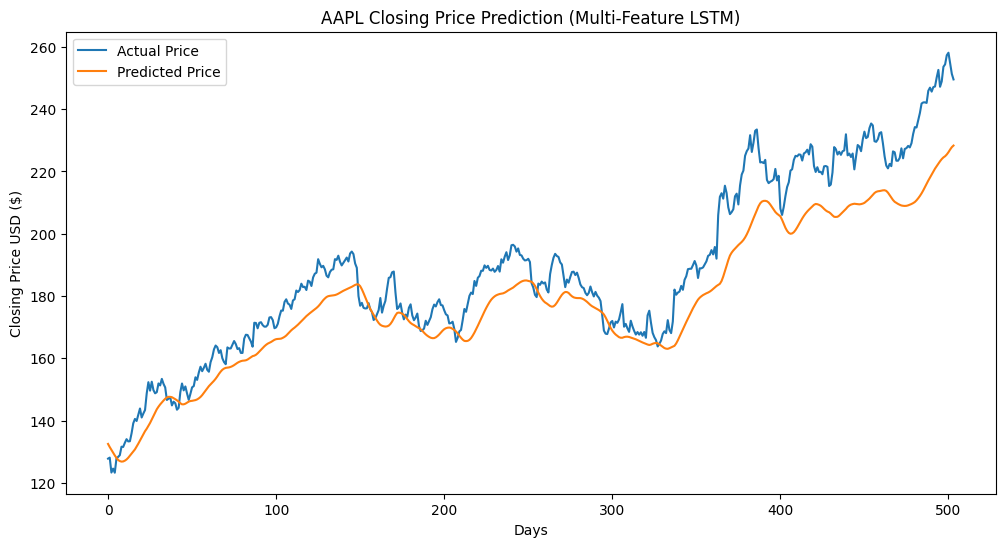

In [ ]:
# Step 12: Plot actual vs predicted
plt.figure(figsize=(12,6))
plt.title(f'{stock_symbol} Closing Price Prediction (Multi-Feature LSTM)')
plt.plot(true_close, label='Actual Price')
plt.plot(predicted_close, label='Predicted Price')
plt.xlabel('Days')
plt.ylabel('Closing Price USD ($)')
plt.legend()
plt.show()

In [ ]:
# --- Define prediction input (X_pred) ---
window_size = 60  # Use the same window size as during training

# Prepare the last sequence from your scaled data
X_pred = scaled_data[-window_size:]
X_pred = np.reshape(X_pred, (1, X_pred.shape[0], X_pred.shape[1]))  # reshape for LSTM input

# --- Make the prediction ---
next_day_scaled_pred = model.predict(X_pred)

# --- Inverse transform the scaled prediction ---
scale_factors = np.zeros((1, scaled_data.shape[1]))
scale_factors[0, target_col] = 1  # only inverse the target column

next_day_price = scaler.inverse_transform(next_day_scaled_pred * scale_factors)[:, target_col]

# --- Format and display result ---
predicted_value = float(next_day_price.flatten()[0])
print(f"💰 Predicted closing price for next trading day: ${predicted_value:.2f}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
💰 Predicted closing price for next trading day: $228.58
